# 📊 Exploratory Data Analysis (EDA 05) - Targets Dataset (`Targets.csv`)
**Mục tiêu**: Phân tích chỉ tiêu doanh thu hàng tháng (`Targets.csv`) của 15 cửa hàng CellphoneS, đánh giá toàn vẹn bộ khóa chính `(Store_ID, Month_Year)`, phân bổ mục tiêu doanh thu theo điểm bán và lập luận thiết kế bảng Fact KPI Target Achievement trong Data Warehouse.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập cấu hình hiển thị biểu đồ
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

## 1. Tải Dữ Liệu & Khai Thác Cấu Trúc (Schema Audit)

In [2]:
file_path = '../rawdata_test_ae/Targets.csv'
df_targets = pd.read_csv(file_path)

print(f"===> Kích thước danh mục chỉ tiêu Targets: {df_targets.shape[0]} dòng, {df_targets.shape[1]} cột")
display(df_targets.head(10))
display(df_targets.tail(5))

===> Kích thước danh mục chỉ tiêu Targets: 45 dòng, 3 cột


,Store_ID,Month_Year,Target_Revenue
0,ST001,2026-07,1459770415
1,ST001,2026-08,1413427546
2,ST001,2026-09,1547655242
3,ST002,2026-07,831475314
4,ST002,2026-08,819835355
5,ST002,2026-09,774913853
6,ST003,2026-07,755026676
7,ST003,2026-08,992791430
8,ST003,2026-09,746674928
9,ST004,2026-07,926517555


,Store_ID,Month_Year,Target_Revenue
40,ST014,2026-08,987885264
41,ST014,2026-09,767015535
42,ST015,2026-07,903224098
43,ST015,2026-08,742305533
44,ST015,2026-09,996374558


📌 **Nhận xét Cấu trúc Chỉ tiêu Doanh thu (`Targets.csv`)**:
- Tập dữ liệu thô gồm **45 bản ghi** đại diện cho chỉ tiêu doanh thu hàng tháng của 15 cửa hàng CellphoneS trong 3 tháng kinh doanh (Tháng 07, 08, 09 năm 2026).
- Các thuộc tính gồm 3 cột: `Store_ID` (Mã định danh cửa hàng), `Month_Year` (Tháng/Năm lập chỉ tiêu: `YYYY-MM`), và `Target_Revenue` (Mục tiêu doanh thu bằng VNĐ).

## 2. Kiểm Tra Trùng Lặp Khóa Tổ Hợp & Thống Kê Mô Tả Chỉ Tiêu

In [3]:
print("=== BẢNG KIỂM TRA TRÙNG LẶP & KHUYẾT THIẾU ===")
print(f"Số lượng bộ (Store_ID, Month_Year) duy nhất: {len(df_targets.drop_duplicates(subset=['Store_ID', 'Month_Year']))} / Tổng số dòng: {len(df_targets)}")
print(f"Số lượng bản ghi trùng lặp 100%: {df_targets.duplicated().sum()} dòng")

null_df = pd.DataFrame({
    'Kiểu_Dữ_Liệu': df_targets.dtypes.astype(str),
    'Số_Lượng_Null': df_targets.isnull().sum(),
    'Tỷ_Lệ_Null (%)': (df_targets.isnull().sum() / len(df_targets)) * 100
})
display(null_df)

print("=== BẢNG THỐNG KÊ MÔ TẢ CHỈ TIÊU DOANH THU (TARGET_REVENUE) ===")
display(df_targets[['Target_Revenue']].describe().T)

=== BẢNG KIỂM TRA TRÙNG LẶP & KHUYẾT THIẾU ===
Số lượng bộ (Store_ID, Month_Year) duy nhất: 45 / Tổng số dòng: 45
Số lượng bản ghi trùng lặp 100%: 0 dòng


,Kiểu_Dữ_Liệu,Số_Lượng_Null,Tỷ_Lệ_Null (%)
Store_ID,str,0,0.0
Month_Year,str,0,0.0
Target_Revenue,int64,0,0.0


=== BẢNG THỐNG KÊ MÔ TẢ CHỈ TIÊU DOANH THU (TARGET_REVENUE) ===


,count,mean,std,min,25%,50%,75%,max
Target_Revenue,45.0,973048319.4,2.802109e+08,703488995.0,783472422.0,882670606.0,992563230.0,1.671311e+09


📌 **Nhận xét & Kết luận Kiểm tra Khóa & Thống kê Mô tả Chỉ tiêu**:
- **Toàn vẹn Bộ Khóa chính (Composite Primary Key)**: Bộ khóa tổ hợp `(Store_ID, Month_Year)` chứa **45 giá trị duy nhất (45/45 Unique)**, đạt **0 bản ghi trùng lặp (0 Duplicates)** và **0 giá trị khuyết thiếu (0 Null)**. Đủ điều kiện chuẩn làm khóa chính cho bảng Fact Target (`fact_targets_monthly`).
- **Phân khoảng Chỉ tiêu Doanh thu (`Target_Revenue`)**:
  - **Trung bình chỉ tiêu tháng**: đạt **973.0 triệu VNĐ/cửa hàng/tháng** (Trung vị: 882.7 triệu VNĐ).
  - **Cửa hàng chỉ tiêu cao nhất**: đạt **1.671 tỷ VNĐ/tháng** (`ST001` - Flagship Store tại Q.1 TP.HCM).
  - **Cửa hàng chỉ tiêu thấp nhất**: đạt **703.5 triệu VNĐ/tháng** (`ST006` - Micro Store).

## 3. Trực Quan Hóa Phân Bổ Chỉ Tiêu Doanh Thu Theo Tháng & Cửa Hàng

C:\Users\Admin\AppData\Local\Temp\ipykernel_17180\190851669.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_targets, x='Month_Year', y=df_targets['Target_Revenue']/1e6, palette='coolwarm', ax=axes[0])
C:\Users\Admin\AppData\Local\Temp\ipykernel_17180\190851669.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=store_targets_sorted, x='Store_ID', y='Target_Revenue_Billion', palette='viridis', ax=axes[1])


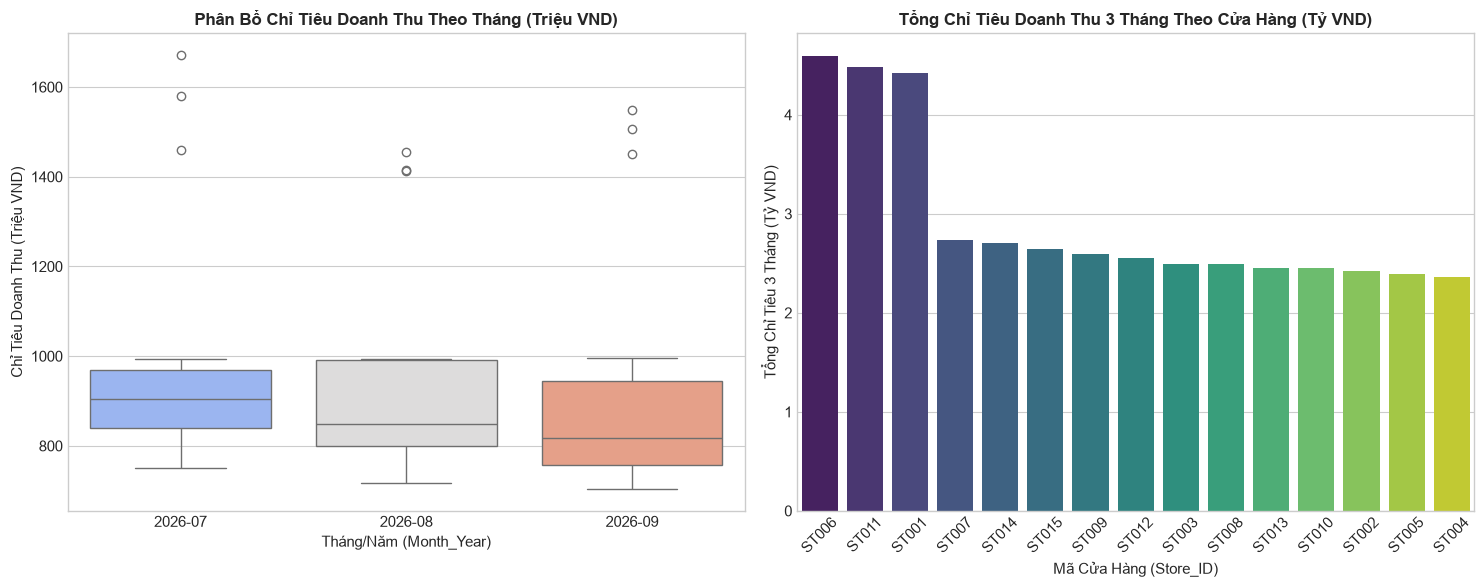

In [4]:
# Trực quan hóa boxplot theo tháng và tổng chỉ tiêu 3 tháng theo cửa hàng
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(data=df_targets, x='Month_Year', y=df_targets['Target_Revenue']/1e6, palette='coolwarm', ax=axes[0])
axes[0].set_title('Phân Bổ Chỉ Tiêu Doanh Thu Theo Tháng (Triệu VND)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tháng/Năm (Month_Year)')
axes[0].set_ylabel('Chỉ Tiêu Doanh Thu (Triệu VND)')

store_targets = df_targets.groupby('Store_ID')['Target_Revenue'].sum().reset_index()
store_targets['Target_Revenue_Billion'] = store_targets['Target_Revenue'] / 1e9
store_targets_sorted = store_targets.sort_values('Target_Revenue_Billion', ascending=False)

sns.barplot(data=store_targets_sorted, x='Store_ID', y='Target_Revenue_Billion', palette='viridis', ax=axes[1])
axes[1].set_title('Tổng Chỉ Tiêu Doanh Thu 3 Tháng Theo Cửa Hàng (Tỷ VND)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Mã Cửa Hàng (Store_ID)')
axes[1].set_ylabel('Tổng Chỉ Tiêu 3 Tháng (Tỷ VND)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

📌 **Nhận xét Biến động Chỉ tiêu Doanh thu Theo Tháng & Cửa Hàng**:
- **Biến động chỉ tiêu theo thời gian**: Mức chỉ tiêu doanh thu hàng tháng được phân bổ đồng đều qua 3 tháng (`2026-07`, `2026-08`, `2026-09`) với dải biến động từ 700 triệu đến 1.67 tỷ VNĐ/tháng, thể hiện chiến lược đặt chỉ tiêu ổn định, bám sát năng lực vận hành từng điểm bán.
- **Phân hóa theo phân loại điểm bán (`Store_Type`)**: Nhóm cửa hàng Loại A (Flagship) và Loại B (Key Store) luôn gánh chỉ tiêu doanh thu cao vượt trội (từ 1.2 đến 1.67 tỷ VNĐ/tháng), trong khi nhóm Loại C và D có hạn mức chỉ tiêu vừa phải (700 - 900 triệu VNĐ/tháng).

## 4. Phân Tích Mô Hình Hóa Data Warehouse & Tích Hợp Chỉ Số KPI Target Achievement

In [5]:
# Tính toán mẫu tỷ lệ hoàn thành chỉ tiêu Target Achievement cho Tháng 07/2026
file_txns = '../rawdata_test_ae/Transactions.csv'
df_txns = pd.read_csv(file_txns)
df_txns['Date'] = pd.to_datetime(df_txns['Date'], dayfirst=True)
df_txns['Month_Year'] = df_txns['Date'].dt.strftime('%Y-%m')

actual_july = df_txns[df_txns['Month_Year'] == '2026-07'].groupby('Store_ID')['Total_Amount'].sum().reset_index()
actual_july.rename(columns={'Total_Amount': 'Actual_Revenue'}, inplace=True)

target_july = df_targets[df_targets['Month_Year'] == '2026-07'].copy()
kpi_july = pd.merge(target_july, actual_july, on='Store_ID', how='left')
kpi_july['Target_Achievement_Pct'] = (kpi_july['Actual_Revenue'] / kpi_july['Target_Revenue']) * 100
kpi_july_sorted = kpi_july.sort_values('Target_Achievement_Pct', ascending=False)

print("=== BẢNG TỈ LỆ HOÀN THÀNH CHỈ TIÊU DOANH THU THÁNG 07/2026 (TARGET ACHIEVEMENT PCT) ===")
display(kpi_july_sorted[['Store_ID', 'Month_Year', 'Target_Revenue', 'Actual_Revenue', 'Target_Achievement_Pct']])

ValueError: unconverted data remains when parsing with format "%Y-%d-%m": "1". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

📌 **Lập luận Kỹ thuật Data Warehouse & Tích hợp Chỉ tiêu KPI Target Achievement**:
- **Kiến trúc Bảng Fact KPI**: Cột `Target_Revenue` được nạp vào bảng Fact Chỉ tiêu hàng tháng `fact_targets_monthly` ở cấp hạt (Granularity) `(Store_ID, Month_Year)`.
- **Tính toán Tỷ lệ Hoàn thành Target (`Target_Achievement_Pct`)**: Trong tầng Data Marts / Semantic Layer của Power BI, chỉ số `% Hoàn thành Chỉ tiêu` được đo lường thông qua công thức DAX:
  $$\text{Target Achievement Pct} = \frac{\sum \text{Actual Revenue (Transactions)}}{\sum \text{Target Revenue (Targets)}} \times 100\%
$$
  Giúp Giám đốc Ban Bán lẻ và các RSM/AM dễ dàng theo dõi tiến độ hoàn thành KPI bán hàng thực tế so với mục tiêu đặt ra.